In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Engle-Granger Test or Cointegration Test

/var/folders/7l/lswfjppn54zc9mlcflv0453m0000gp/T/ipykernel_57590/977689162.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("financial_data_completes.csv", parse_dates=["Month"], index_col="Month")


            Food CPI  Subsidy_Index  TRI_norm  FAO Food Price Index  FAO Meat  \
Month                                                                           
2000-01-01     -5.34       0.737463       0.0                  52.8      60.6   
2000-02-01     -2.19       0.737463       0.0                  52.5      60.9   
2000-03-01      5.86       0.737463       1.0                  53.1      62.8   
2000-04-01     -1.20       0.737463       1.0                  53.7      62.3   
2000-05-01     -0.32       0.737463       1.0                  54.0      63.3   

            FAO Dairy Index  FAO Cereals Index  FAO Oils Index  \
Month                                                            
2000-01-01             50.2               52.1           48.58   
2000-02-01             50.4               52.2           46.37   
2000-03-01             50.1               51.7           47.82   
2000-04-01             50.4               51.8           49.50   
2000-05-01             50.9         

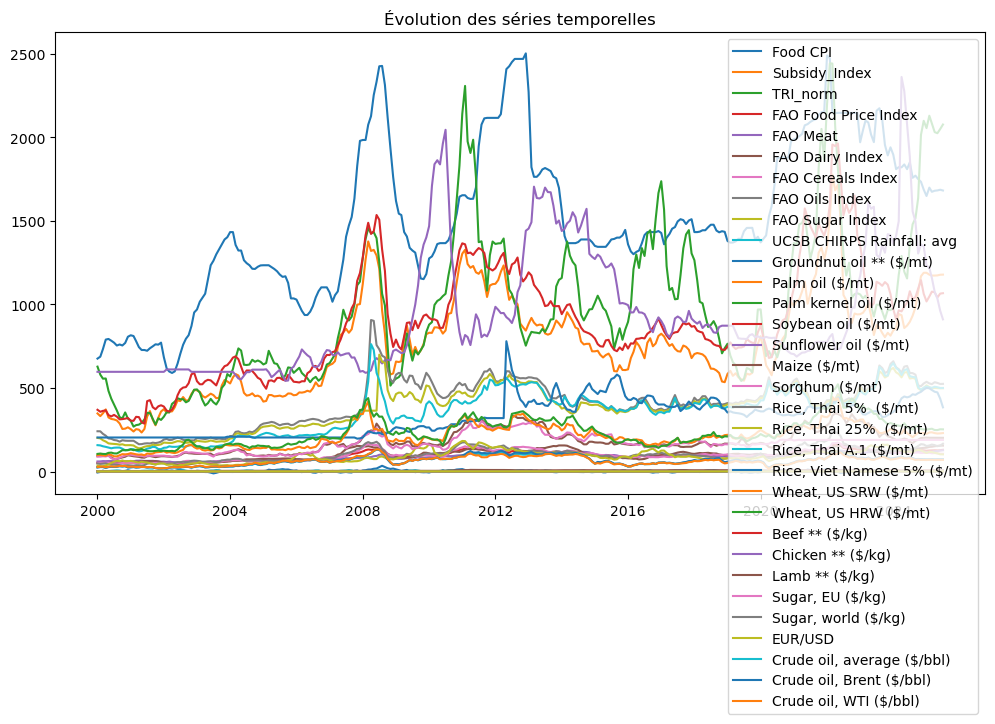

Test de co-intégration entre Food CPI et Subsidy_Index
Statistique: -3.7789, p-value: 0.0145
=> Ces séries sont co-intégrées ✅

Test de co-intégration entre Food CPI et TRI_norm
Statistique: -3.7780, p-value: 0.0145
=> Ces séries sont co-intégrées ✅

Test de co-intégration entre Food CPI et FAO Food Price Index
Statistique: -3.6940, p-value: 0.0187
=> Ces séries sont co-intégrées ✅

Test de co-intégration entre Food CPI et FAO Meat
Statistique: -3.7995, p-value: 0.0136
=> Ces séries sont co-intégrées ✅

Test de co-intégration entre Food CPI et FAO Dairy Index
Statistique: -3.7455, p-value: 0.0160
=> Ces séries sont co-intégrées ✅

Test de co-intégration entre Food CPI et FAO Cereals Index
Statistique: -3.6748, p-value: 0.0197
=> Ces séries sont co-intégrées ✅

Test de co-intégration entre Food CPI et FAO Oils Index
Statistique: -3.6672, p-value: 0.0202
=> Ces séries sont co-intégrées ✅

Test de co-intégration entre Food CPI et FAO Sugar Index
Statistique: -3.7812, p-value: 0.0144
=> Ce

In [3]:
# === 1. Charger vos données ===
df = pd.read_csv("financial_data_completes.csv", parse_dates=["Month"], index_col="Month")
print(df.head())

# === 2. Visualiser les séries ===
plt.figure(figsize=(12, 6))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)
plt.legend()
plt.title("Évolution des séries temporelles")
plt.show()

# === 3. Vérifier la co-intégration par la méthode d'Engle-Granger ===
# Test de co-intégration entre deux séries
def test_coint(series1, series2, alpha=0.05):
    score, p_value, _ = coint(series1, series2)
    print(f"Test de co-intégration entre {series1.name} et {series2.name}")
    print(f"Statistique: {score:.4f}, p-value: {p_value:.4f}")
    if p_value < alpha:
        print("=> Ces séries sont co-intégrées ✅\n")
    else:
        print("=> Ces séries ne sont pas co-intégrées ❌\n")

# Tester toutes les paires de séries
cols = df.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        test_coint(df[cols[i]], df[cols[j]])

# Johansen Test

/var/folders/7l/lswfjppn54zc9mlcflv0453m0000gp/T/ipykernel_57590/1651914760.py:3: HypothesisTestWarning: Critical values are only available for time series with 12 variables at most.
  result = coint_johansen(data, det_order, k_ar_diff)



=== Test de Johansen ===
Valeur propre 1: statistique trace = 3037.6810
Valeurs critiques (90%, 95%, 99%): [nan nan nan]
=> Pas de co-intégration à 95% ❌

Valeur propre 2: statistique trace = 2762.3557
Valeurs critiques (90%, 95%, 99%): [nan nan nan]
=> Pas de co-intégration à 95% ❌

Valeur propre 3: statistique trace = 2499.2149
Valeurs critiques (90%, 95%, 99%): [nan nan nan]
=> Pas de co-intégration à 95% ❌

Valeur propre 4: statistique trace = 2283.6472
Valeurs critiques (90%, 95%, 99%): [nan nan nan]
=> Pas de co-intégration à 95% ❌

Valeur propre 5: statistique trace = 2073.7773
Valeurs critiques (90%, 95%, 99%): [nan nan nan]
=> Pas de co-intégration à 95% ❌

Valeur propre 6: statistique trace = 1893.5652
Valeurs critiques (90%, 95%, 99%): [nan nan nan]
=> Pas de co-intégration à 95% ❌

Valeur propre 7: statistique trace = 1721.3773
Valeurs critiques (90%, 95%, 99%): [nan nan nan]
=> Pas de co-intégration à 95% ❌

Valeur propre 8: statistique trace = 1562.7052
Valeurs critiques

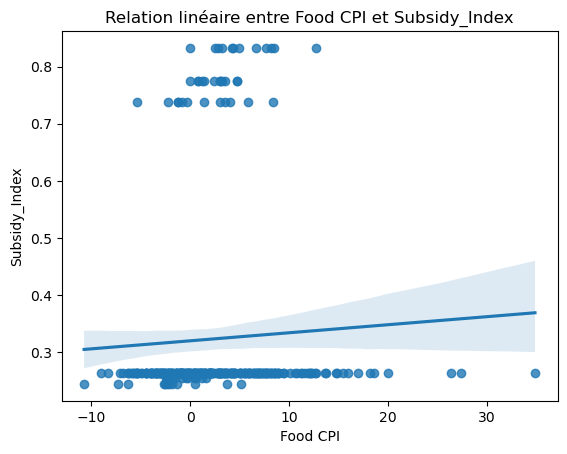

In [4]:

# === 4. Vérifier la co-intégration avec le test de Johansen ===
def johansen_test(data, det_order=0, k_ar_diff=1):
    result = coint_johansen(data, det_order, k_ar_diff)
    trace_stat = result.lr1
    crit_values = result.cvt

    print("\n=== Test de Johansen ===")
    for i in range(len(trace_stat)):
        print(f"Valeur propre {i+1}: statistique trace = {trace_stat[i]:.4f}")
        print(f"Valeurs critiques (90%, 95%, 99%): {crit_values[i]}")
        if trace_stat[i] > crit_values[i, 1]:
            print("=> Il y a une co-intégration à 95% ✅\n")
        else:
            print("=> Pas de co-intégration à 95% ❌\n")

# Appliquer Johansen sur toutes les colonnes
johansen_test(df)

# === 5. Visualiser la relation entre deux séries co-intégrées ===
sns.regplot(x=df[cols[0]], y=df[cols[1]])
plt.title(f"Relation linéaire entre {cols[0]} et {cols[1]}")
plt.show()


# Max Eigenvalue